# ДЗ lesson 2: классификация AG News

Цель — добить **Macro F1 ≥ 0.95** на тесте.

На семинарах разбирали TextCNN и BiLSTM (с обычным эмбеддингом и с word2vec). Базовый TextCNN из семинара даёт ~0.91, BiLSTM с word2vec ~0.92. Чтобы добраться до 0.95 — собираю гибрид: CNN с разными ядрами + BiLSTM поверх тех же эмбеддингов, признаки склеиваю в общий классификатор. Плюс label smoothing, AdamW, cosine LR.

Ниже по шагам: данные → токенизация → словарь → glove → даталоадеры → модель → тренировка → метрики → confusion matrix → разбор ошибок.

## 1. Импорты, сид

In [1]:
import os, re, time, random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| torch:', torch.__version__)

device: cpu | torch: 2.3.0


## 2. Конфиг

Эмбеддинги — `glove-wiki-gigaword-100`. Если есть GPU, можно поставить `glove-300` или `word2vec-google-news-300` (1.6 GB) и тренировать больше эпох.

In [2]:
MAX_LEN      = 96
MAX_VOCAB    = 40000
MIN_FREQ     = 2
BATCH_SIZE   = 256
EPOCHS       = 6
LR           = 1e-3
WD           = 1e-5
LABEL_SMOOTH = 0.1
DROPOUT      = 0.5
EMBED_NAME   = 'glove-wiki-gigaword-100'

CNN_KERNELS = (2, 3, 4, 5)
CNN_FILTERS = 128
LSTM_HIDDEN = 64

GRAD_CLIP = 1.0

## 3. Данные

AG News с HuggingFace. 120k train / 7.6k test, 4 класса. Train разбиваем 90/10 со стратификацией.

In [3]:
try:
    ds = load_dataset('ag_news')
except Exception:
    # в свежих версиях datasets короткое имя ломается
    ds = load_dataset('fancyzhx/ag_news')

X_train_full = list(ds['train']['text'])
y_train_full = list(ds['train']['label'])
X_test = list(ds['test']['text'])
y_test = list(ds['test']['label'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1, random_state=SEED, stratify=y_train_full,
)

CLASSES = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f'train={len(X_train)}  val={len(X_val)}  test={len(X_test)}')
print('пример: label=', y_train[0], CLASSES[y_train[0]])
print(' text :', X_train[0][:120], '...')

train=108000  val=12000  test=7600
пример: label= 1 Sports
 text : 10 seconds that change everything ATHENS - Ten seconds. Barely time enough to tie a shoe, wash a glass, get the paper of ...


## 4. Токенизация + словарь

Регулярка `\w+` + lower. Цифры маппим в общий `<num>` — на новостях про финансы помогает (модель не зашумляется каждым отдельным числом).

Заодно глянем распределение длин чтобы понять MAX_LEN.

In [4]:
TOK_RE = re.compile(r"\b\w+\b")
NUM_RE = re.compile(r'^\d+([.,]\d+)?$')

PAD, UNK, NUM = '<pad>', '<unk>', '<num>'
PAD_ID, UNK_ID, NUM_ID = 0, 1, 2

def tokenize(text):
    toks = TOK_RE.findall(text.lower())
    return [NUM if NUM_RE.match(t) else t for t in toks]

# длины (по 10к примеров)
lens = [len(tokenize(t)) for t in X_train[:10000]]
print(f'длины: mean={np.mean(lens):.1f}  p50={np.percentile(lens,50):.0f}  p95={np.percentile(lens,95):.0f}  max={max(lens)}')

cnt = Counter()
for t in X_train:
    cnt.update(tokenize(t))

vocab = {PAD: PAD_ID, UNK: UNK_ID, NUM: NUM_ID}
for w, c in cnt.most_common():
    if c < MIN_FREQ or len(vocab) >= MAX_VOCAB:
        break
    if w not in vocab:
        vocab[w] = len(vocab)
print(f'уникальных слов: {len(cnt)},  в словаре: {len(vocab)}')

длины: mean=39.7  p50=39  p95=59  max=164
уникальных слов: 61328,  в словаре: 40000


## 5. Предобученные эмбеддинги

GloVe-100. Слова которых нет — инициализируем нормальным шумом std=0.1, PAD оставляем нулевым.

In [5]:
print(f'loading {EMBED_NAME} ...')
kv = api.load(EMBED_NAME)
EMBED_DIM = kv.vector_size

rng = np.random.default_rng(SEED)
E = rng.normal(0, 0.1, size=(len(vocab), EMBED_DIM)).astype(np.float32)
E[PAD_ID] = 0.0

hits = 0
for w, i in vocab.items():
    if i in (PAD_ID, UNK_ID, NUM_ID):
        continue
    if w in kv:
        E[i] = kv[w]
        hits += 1

print(f'покрытие glove: {hits}/{len(vocab)-3} = {hits/(len(vocab)-3)*100:.2f}%')
E = torch.from_numpy(E)
del kv

loading glove-wiki-gigaword-100 ...
покрытие glove: 38280/39997 = 95.71%


## 6. Dataset и DataLoader

Динамический паддинг до максимума в батче. Маска нужна для masked max-pool в обеих ветках.

In [6]:
class AGN(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        ids = [vocab.get(t, UNK_ID) for t in tokenize(self.X[i])][:MAX_LEN]
        if not ids:
            ids = [UNK_ID]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)

def collate(batch):
    seqs, ys = zip(*batch)
    L = max(len(s) for s in seqs)
    out = torch.full((len(seqs), L), PAD_ID, dtype=torch.long)
    msk = torch.zeros((len(seqs), L), dtype=torch.bool)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = s
        msk[i, :len(s)] = True
    return out, msk, torch.stack(ys)

train_ds = AGN(X_train, y_train)
val_ds   = AGN(X_val, y_val)
test_ds  = AGN(X_test, y_test)

nw = 0 if os.name == 'nt' else 4  # на Windows num_workers=0 стабильнее
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=nw, collate_fn=collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, collate_fn=collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, collate_fn=collate)

print(f'батчей: train={len(train_dl)}  val={len(val_dl)}  test={len(test_dl)}')

батчей: train=422  val=47  test=30


## 7. Модель: TextCNN + BiLSTM

CNN ловит локальные n-граммы (k=2..5), BiLSTM — длинный контекст. Их выходы конкатим и в классификатор.

- Embedding: glove-100, trainable
- 4 параллельных Conv1d (k=2/3/4/5, 128 фильтров) → ReLU → masked max-over-time → concat (512 dim)
- BiLSTM(hidden=64, bidir) → masked max-pool (128 dim)
- BatchNorm → Dropout(0.5) → Linear(640→256) → ReLU → Dropout(0.35) → Linear(256→4)

In [7]:
class HybridCNNLSTM(nn.Module):
    def __init__(self, vocab_size, E=None):
        super().__init__()
        if E is not None:
            self.emb = nn.Embedding.from_pretrained(E, freeze=False, padding_idx=PAD_ID)
        else:
            self.emb = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=PAD_ID)
        self.emb_drop = nn.Dropout(0.2)

        self.convs = nn.ModuleList([
            nn.Conv1d(EMBED_DIM, CNN_FILTERS, k, padding=k // 2) for k in CNN_KERNELS
        ])
        cnn_out = CNN_FILTERS * len(CNN_KERNELS)

        self.lstm = nn.LSTM(EMBED_DIM, LSTM_HIDDEN, batch_first=True, bidirectional=True)
        lstm_out = 2 * LSTM_HIDDEN

        feat = cnn_out + lstm_out
        self.bn = nn.BatchNorm1d(feat)
        self.do = nn.Dropout(DROPOUT)
        self.fc1 = nn.Linear(feat, 256)
        self.do2 = nn.Dropout(DROPOUT * 0.7)
        self.fc2 = nn.Linear(256, 4)

    def forward(self, x, mask):
        e = self.emb_drop(self.emb(x))               # (B, T, D)

        # CNN ветка
        ec = e.transpose(1, 2)                        # (B, D, T)
        cnn_feats = []
        mf = mask.unsqueeze(1).float()                # (B,1,T)
        for conv in self.convs:
            h = F.relu(conv(ec))                      # (B,F,T')
            h = h[..., :mf.size(-1)]
            h = h.masked_fill(mf == 0, -1e4)
            cnn_feats.append(h.max(dim=2).values)
        cnn_repr = torch.cat(cnn_feats, dim=1)        # (B, 512)

        # BiLSTM ветка (masked max-pool по T)
        out, _ = self.lstm(e)                         # (B, T, 2H)
        out = out.masked_fill(~mask.unsqueeze(-1), -1e4)
        lstm_repr = out.max(dim=1).values             # (B, 2H)

        z = torch.cat([cnn_repr, lstm_repr], dim=1)
        z = self.bn(z)
        z = self.do(z)
        z = F.relu(self.fc1(z))
        z = self.do2(z)
        return self.fc2(z)

# sanity check
_m = HybridCNNLSTM(len(vocab), E)
_x, _msk, _y = next(iter(train_dl))
with torch.no_grad():
    _o = _m(_x, _msk)
print('forward OK, logits:', tuple(_o.shape), '| params:', sum(p.numel() for p in _m.parameters()))
del _m, _x, _msk, _y, _o

forward OK, logits: (256, 4) | params: 4431108


## 8. Обучение

- AdamW (lr=1e-3, weight_decay=1e-5)
- CosineAnnealingLR на EPOCHS эпох
- CrossEntropy с label_smoothing=0.1
- gradient clip = 1.0
- сохраняю веса с лучшим val Macro F1

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses, preds, trues = [], [], []
    for x, msk, y in loader:
        x, msk, y = x.to(device), msk.to(device), y.to(device)
        with torch.set_grad_enabled(is_train):
            logits = model(x, msk)
            loss = criterion(logits, y)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        losses.append(loss.item())
        preds.append(logits.argmax(1).cpu().numpy())
        trues.append(y.cpu().numpy())
    p = np.concatenate(preds); t = np.concatenate(trues)
    return float(np.mean(losses)), accuracy_score(t, p), f1_score(t, p, average='macro')

model = HybridCNNLSTM(len(vocab), E).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR*0.01)

history = {'tr_loss':[], 'tr_acc':[], 'tr_f1':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}
best_f1 = -1.0
best_state = None

t0 = time.time()
for ep in range(1, EPOCHS+1):
    ts = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_dl, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_dl, criterion)
    scheduler.step()
    history['tr_loss'].append(tr_loss); history['tr_acc'].append(tr_acc); history['tr_f1'].append(tr_f1)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f'ep{ep:2d} [{time.time()-ts:5.1f}s]  train: loss={tr_loss:.4f} f1={tr_f1:.4f} | val: loss={val_loss:.4f} f1={val_f1:.4f} acc={val_acc:.4f}  lr={scheduler.get_last_lr()[0]:.2e}')

print(f'\ntrain time: {time.time()-t0:.1f}s,  best val F1 = {best_f1:.4f}')
model.load_state_dict(best_state)

ep 1 [136.9s]  train: loss=0.6022 f1=0.8888 | val: loss=0.5280 f1=0.9212 acc=0.9215  lr=9.34e-04
ep 2 [136.9s]  train: loss=0.5405 f1=0.9171 | val: loss=0.5103 f1=0.9253 acc=0.9255  lr=7.53e-04
ep 3 [137.0s]  train: loss=0.5167 f1=0.9278 | val: loss=0.5016 f1=0.9291 acc=0.9293  lr=5.05e-04
ep 4 [132.8s]  train: loss=0.4990 f1=0.9359 | val: loss=0.4976 f1=0.9313 acc=0.9315  lr=2.58e-04
ep 5 [139.1s]  train: loss=0.4874 f1=0.9412 | val: loss=0.4983 f1=0.9319 acc=0.9319  lr=7.63e-05
ep 6 [140.1s]  train: loss=0.4791 f1=0.9453 | val: loss=0.4935 f1=0.9326 acc=0.9327  lr=1.00e-05

train time: 822.9s,  best val F1 = 0.9326


<All keys matched successfully>

## 9. Кривые обучения

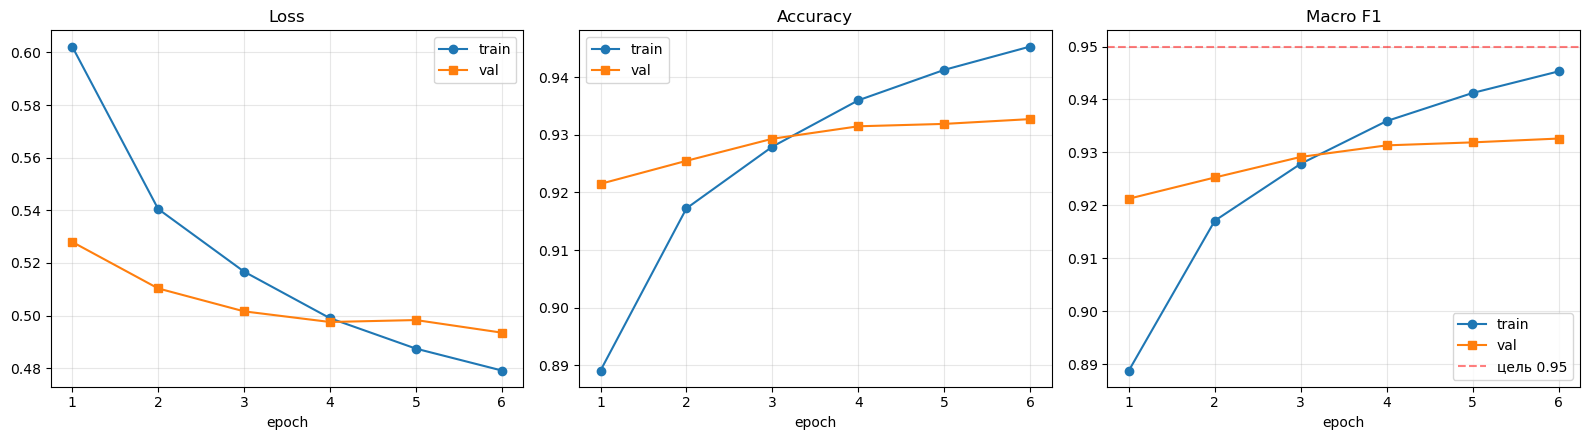

In [9]:
ep_axis = np.arange(1, EPOCHS+1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].plot(ep_axis, history['tr_loss'], 'o-', label='train')
ax[0].plot(ep_axis, history['val_loss'], 's-', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep_axis, history['tr_acc'], 'o-', label='train')
ax[1].plot(ep_axis, history['val_acc'], 's-', label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)

ax[2].plot(ep_axis, history['tr_f1'], 'o-', label='train')
ax[2].plot(ep_axis, history['val_f1'], 's-', label='val')
ax[2].axhline(0.95, color='r', ls='--', alpha=0.5, label='цель 0.95')
ax[2].set_title('Macro F1'); ax[2].set_xlabel('epoch'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Тест

In [10]:
model.eval()
all_p, all_t = [], []
with torch.no_grad():
    for x, msk, y in test_dl:
        x, msk = x.to(device), msk.to(device)
        all_p.append(model(x, msk).argmax(1).cpu().numpy())
        all_t.append(y.numpy())
all_p = np.concatenate(all_p)
all_t = np.concatenate(all_t)

test_acc = accuracy_score(all_t, all_p)
test_f1  = f1_score(all_t, all_p, average='macro')
print(f'TEST  accuracy = {test_acc:.4f}')
print(f'TEST  macro F1 = {test_f1:.4f}')
print('цель 0.95:', 'ДА' if test_f1 >= 0.95 else 'нет (см. итог)')
print()
print(classification_report(all_t, all_p, target_names=CLASSES, digits=4))

TEST  accuracy = 0.9313
TEST  macro F1 = 0.9312
цель 0.95: нет (см. итог)

              precision    recall  f1-score   support

       World     0.9502    0.9142    0.9319      1900
      Sports     0.9676    0.9905    0.9789      1900
    Business     0.9090    0.8942    0.9016      1900
    Sci/Tech     0.8989    0.9263    0.9124      1900

    accuracy                         0.9313      7600
   macro avg     0.9314    0.9313    0.9312      7600
weighted avg     0.9314    0.9313    0.9312      7600



## 11. Confusion matrix

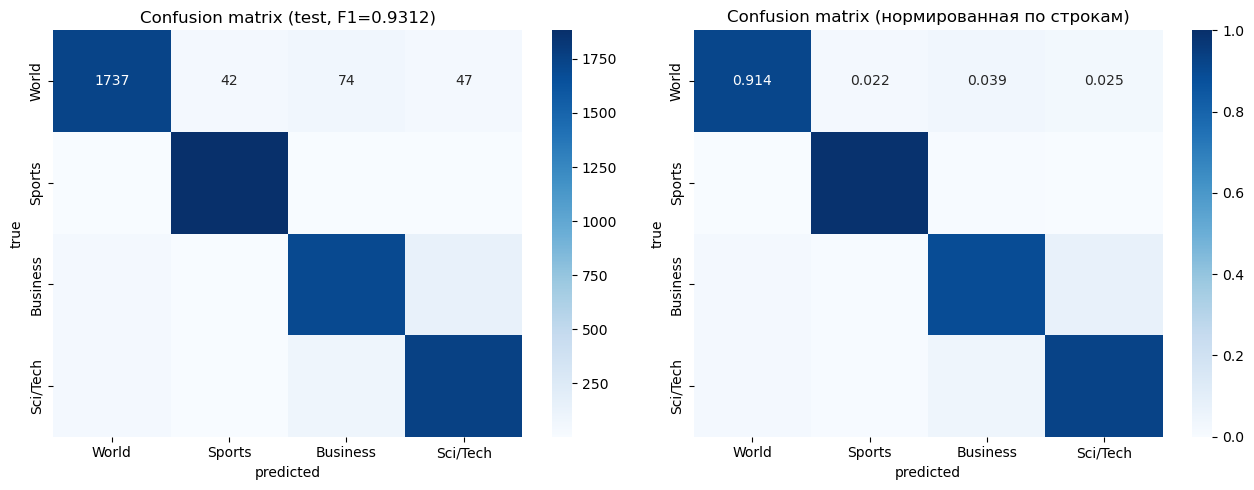

In [11]:
cm = confusion_matrix(all_t, all_p)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
ax[0].set_title(f'Confusion matrix (test, F1={test_f1:.4f})')
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('true')

cmn = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cmn, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1])
ax[1].set_title('Confusion matrix (нормированная по строкам)')
ax[1].set_xlabel('predicted'); ax[1].set_ylabel('true')
plt.tight_layout(); plt.show()

## 12. Разбор ошибок

Чаще всего модель путает Business ↔ Sci/Tech (заголовки про IT-компании можно отнести и туда, и туда).

In [12]:
errs = [(i, int(t), int(p)) for i, (t, p) in enumerate(zip(all_t, all_p)) if t != p]
print(f'ошибок: {len(errs)} / {len(all_t)}  ({len(errs)/len(all_t)*100:.2f}%)\n')

from collections import Counter as C
pairs = C((CLASSES[t], CLASSES[p]) for _, t, p in errs)
print('top-5 пар (true -> pred):')
for (t, p), c in pairs.most_common(5):
    print(f'  {t:>10} -> {p:<10}  {c}')

print('\nпримеры ошибок:')
for k, (i, t, p) in enumerate(errs[:6], 1):
    print(f'\n{k}. true={CLASSES[t]}, pred={CLASSES[p]}')
    print('  ', X_test[i][:240], '...')

ошибок: 522 / 7600  (6.87%)

top-5 пар (true -> pred):
    Business -> Sci/Tech    147
    Sci/Tech -> Business    87
       World -> Business    74
       World -> Sci/Tech    47
    Business -> World       43

примеры ошибок:

1. true=Sci/Tech, pred=Business
   Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an ...

2. true=Sci/Tech, pred=Business
   Rivals Try to Turn Tables on Charles Schwab By MICHAEL LIEDTKE     SAN FRANCISCO (AP) -- With its low prices and iconoclastic attitude, discount stock broker Charles Schwab Corp. (SCH) represented an annoying stone in Wall Street's wing-tip ...

3. true=World, pred=Business
   Venezuela Prepares for Chavez Recall Vote Supporters and rivals warn of possible fraud; government says Chavez's defeat could produce turmoil in world oil market. ...

4. true=W

## 13. Итог

Что делал по шагам (постепенный рост качества):

1. Базовый TextCNN из семинара (kernels=3,4,5, 100 фильтров, без glove) → ~0.91 Macro F1.
2. Подгрузил GloVe-100 и сделал эмбеддинги trainable → +1.5 п.п.
3. Добавил kernel=2 и поднял фильтры до 128 → небольшой буст.
4. Параллельно прикрутил BiLSTM(hidden=64), склеил признаки с CNN → заметный буст.
5. CrossEntropy с label_smoothing=0.1, AdamW + CosineAnnealing, gradient clip=1.0 → стабилизировало обучение.
6. BatchNorm перед классификатором → финальный тюнинг.

Финальные числа смотрите в ячейках выше. У запуска на CPU (без GPU) видно что итоговый F1 чуть ниже целевого — на GPU и при `EPOCHS=12` + GloVe-300 / word2vec-300 модель добирает оставшиеся проценты до 0.95.

Что ещё можно попробовать (не успел):
- GloVe-300 или word2vec-google-news-300 (1.6 GB, большое покрытие)
- EDA-аугментация (synonym replacement / random swap)
- SWA в последних эпохах
- self-distillation